# Algoritmos Genéticos aplicados a Machine Learning
## Notebook 3: Neuroevolución (Neuroevolution): búsqueda de arquitectura de red neuronal con Algoritmos Genéticos


**Objetivo:** usar un Algoritmo Genético para buscar automáticamente la **arquitectura y algunos hiperparámetros de entrenamiento** de una red neuronal (Keras/TensorFlow), en lugar de definirla manualmente por prueba y error. Esta técnica se conoce como **Neuroevolution** (NE) y es la base de enfoques más avanzados como NEAT.

**Dataset:** el mismo dataset real **Breast Cancer Wisconsin (Diagnostic)** de scikit-learn (569 pacientes, 30 variables reales, diagnóstico maligno/benigno) usado en los notebooks 1 y 2.

---
### 1. ¿Por qué neuroevolución?

Diseñar una red neuronal implica decidir: número de capas ocultas, número de neuronas por capa, función de activación, tasa de dropout y tasa de aprendizaje. Ese espacio de diseño es grande, mixto (discreto + continuo) y no diferenciable respecto del desempeño final, por lo que no se puede optimizar con descenso de gradiente. Un AG sí puede explorarlo de forma natural, tratando cada arquitectura candidata como un cromosoma.


In [1]:
# =========================================================
# Dataset : Breast Cancer Wisconsin (Diagnostic) - sklearn
# Clasificacion binaria: tumor maligno (1) vs. benigno (0)
# =========================================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

datos = load_breast_cancer()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
# En sklearn, target=0 es "malignant" y target=1 es "benign".
# Redefinimos para que 1 = maligno (caso positivo de interes clinico).
df["diagnostico"] = 1 - datos.target

n_malignos = int((df["diagnostico"] == 1).sum())
n_benignos = int((df["diagnostico"] == 0).sum())

print("Dimensiones del dataset:", df.shape)
print(f"Casos malignos: {n_malignos} | Casos benignos: {n_benignos}")
print("Distribucion de la variable objetivo (diagnostico):")
print(df["diagnostico"].value_counts(normalize=True).round(3))
df.head()


Dimensiones del dataset: (569, 31)
Casos malignos: 212 | Casos benignos: 357
Distribucion de la variable objetivo (diagnostico):
diagnostico
0    0.627
1    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 2. Preparación de datos para la red neuronal

Las redes neuronales son sensibles a la escala de las variables, por lo que se estandarizan (media 0, desviación 1) usando únicamente estadísticas del conjunto de entrenamiento.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

tf.get_logger().setLevel("ERROR")

X = df.drop(columns=["diagnostico"]).values
y = df["diagnostico"].values
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.25, stratify=y, random_state=21)
escalador = StandardScaler().fit(Xtr)
Xtr, Xval = escalador.transform(Xtr), escalador.transform(Xval)
n_entradas = Xtr.shape[1]
print("Forma de entrenamiento:", Xtr.shape, "| Forma de validación:", Xval.shape)

Forma de entrenamiento: (426, 30) | Forma de validación: (143, 30)


### 3. Diseño del Algoritmo Genético — Ciclo completo

| Componente | Diseño en este notebook |
|---|---|
| **Representación (cromosoma)** | Diccionario que codifica una arquitectura: `n_capas` (1 a 3 capas ocultas), `n1`, `n2`, `n3` (neuronas por capa, 8–64, se usan solo las primeras `n_capas`), `activacion` (`relu` o `tanh`), `dropout` (0.0–0.5) y `lr` (tasa de aprendizaje, escala logarítmica ~0.0005–0.01). |
| **Inicialización** | Cada gen se muestrea al azar dentro de su rango. |
| **Función de aptitud (fitness)** | Accuracy de validación tras entrenar la red 8 épocas (búsqueda rápida), con una **penalización leve por número de parámetros** (para preferir redes más chicas ante empates). |
| **Selección** | Torneo de tamaño 3. |
| **Cruce (crossover)** | Cruce uniforme gen a gen (cada gen se hereda de un padre u otro con 50% de probabilidad). |
| **Mutación** | Mutación específica por tipo de gen: +-1 capa, +-16 neuronas, cambio de activación, ruido gaussiano en dropout, y escalamiento log-uniforme en la tasa de aprendizaje. |
| **Elitismo** | Los 2 mejores individuos pasan intactos a la siguiente generación. |
| **Terminación** | Máximo 6 generaciones, o 3 generaciones consecutivas sin mejora. |

**Nota de cómputo:** durante la búsqueda evolutiva se entrena cada arquitectura candidata solo 8 épocas (para explorar más arquitecturas en menos tiempo) y se usa una **caché** para no reentrenar arquitecturas repetidas. La arquitectura ganadora se reentrena al final con más épocas.


In [3]:
import numpy as np
rng = np.random.default_rng(21)

ACTIVACIONES = ["relu", "tanh"]
CACHE = {}

#### 3.1 Representación e inicialización

In [4]:
def cromosoma_aleatorio():
    return {
        "n_capas": int(rng.integers(1, 4)),
        "n1": int(rng.integers(8, 65)),
        "n2": int(rng.integers(8, 65)),
        "n3": int(rng.integers(8, 65)),
        "activacion": ACTIVACIONES[rng.integers(0, 2)],
        "dropout": round(float(rng.uniform(0.0, 0.5)), 3),
        "lr": round(float(10 ** rng.uniform(-3.3, -2.0)), 5),
    }

def clave(ind):
    return tuple(ind[k] for k in ["n_capas", "n1", "n2", "n3", "activacion", "dropout", "lr"])

def construir_modelo(ind):
    neuronas = [ind["n1"], ind["n2"], ind["n3"]][: ind["n_capas"]]
    modelo = tf.keras.Sequential([tf.keras.layers.Input(shape=(n_entradas,))])
    for n in neuronas:
        modelo.add(tf.keras.layers.Dense(n, activation=ind["activacion"]))
        if ind["dropout"] > 0:
            modelo.add(tf.keras.layers.Dropout(ind["dropout"]))
    modelo.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    modelo.compile(optimizer=tf.keras.optimizers.Adam(ind["lr"]),
                    loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

#### 3.2 Función de aptitud (fitness), con caché

In [5]:
def fitness_de_cromosoma(ind, epocas=8):
    k = clave(ind)
    if k in CACHE:
        return CACHE[k]
    tf.keras.backend.clear_session()
    modelo = construir_modelo(ind)
    hist = modelo.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epocas,
                       batch_size=64, verbose=0)
    val_acc = hist.history["val_accuracy"][-1]
    n_params = modelo.count_params()
    penalizacion = min(n_params / 20000, 0.05)  # leve preferencia por redes mas chicas
    aptitud = val_acc - penalizacion
    CACHE[k] = aptitud
    return aptitud

#### 3.3 Selección, cruce y mutación

In [6]:
def seleccion_torneo(poblacion, aptitudes, k=3):
    idxs = rng.integers(0, len(poblacion), size=k)
    mejor = idxs[np.argmax([aptitudes[i] for i in idxs])]
    return poblacion[mejor].copy()

def cruce_uniforme(p1, p2, prob=0.5):
    hijo1, hijo2 = {}, {}
    for gen in p1:
        if rng.random() < prob:
            hijo1[gen], hijo2[gen] = p1[gen], p2[gen]
        else:
            hijo1[gen], hijo2[gen] = p2[gen], p1[gen]
    return hijo1, hijo2

def mutacion(ind, prob=0.3):
    hijo = ind.copy()
    if rng.random() < prob:
        hijo["n_capas"] = int(np.clip(hijo["n_capas"] + rng.choice([-1, 1]), 1, 3))
    for gen in ["n1", "n2", "n3"]:
        if rng.random() < prob:
            hijo[gen] = int(np.clip(hijo[gen] + rng.integers(-16, 17), 8, 64))
    if rng.random() < prob:
        hijo["activacion"] = ACTIVACIONES[rng.integers(0, 2)]
    if rng.random() < prob:
        hijo["dropout"] = round(float(np.clip(hijo["dropout"] + rng.normal(0, 0.1), 0.0, 0.5)), 3)
    if rng.random() < prob:
        hijo["lr"] = round(float(np.clip(hijo["lr"] * (10 ** rng.uniform(-0.3, 0.3)), 0.0003, 0.02)), 5)
    return hijo

#### 3.4 Ciclo completo del Algoritmo Genético

In [7]:
def algoritmo_genetico(tam_poblacion=8, generaciones=6, prob_cruce=0.8, prob_mutacion=0.3,
                        elitismo=2, paciencia=3, verbose=True):
    poblacion = [cromosoma_aleatorio() for _ in range(tam_poblacion)]
    historial_mejor, historial_promedio = [], []
    mejor_global, mejor_aptitud_global = None, -1
    sin_mejora = 0

    for gen in range(1, generaciones + 1):
        aptitudes = [fitness_de_cromosoma(ind) for ind in poblacion]
        orden = np.argsort(aptitudes)[::-1]
        poblacion = [poblacion[i] for i in orden]
        aptitudes = [aptitudes[i] for i in orden]

        historial_mejor.append(aptitudes[0])
        historial_promedio.append(float(np.mean(aptitudes)))

        if aptitudes[0] > mejor_aptitud_global:
            mejor_aptitud_global = aptitudes[0]
            mejor_global = poblacion[0].copy()
            sin_mejora = 0
        else:
            sin_mejora += 1

        if verbose:
            arq = [mejor_global["n1"], mejor_global["n2"], mejor_global["n3"]][:mejor_global["n_capas"]]
            print(f"Gen {gen} | mejor={aptitudes[0]:.4f} | promedio={np.mean(aptitudes):.4f} | arq_top={arq}")

        if sin_mejora >= paciencia:
            print(f"Terminación anticipada: sin mejora en {paciencia} generaciones consecutivas.")
            break

        nueva = poblacion[:elitismo]
        while len(nueva) < tam_poblacion:
            p1 = seleccion_torneo(poblacion, aptitudes)
            p2 = seleccion_torneo(poblacion, aptitudes)
            if rng.random() < prob_cruce:
                h1, h2 = cruce_uniforme(p1, p2)
            else:
                h1, h2 = p1.copy(), p2.copy()
            h1, h2 = mutacion(h1, prob_mutacion), mutacion(h2, prob_mutacion)
            nueva.extend([h1, h2])
        poblacion = nueva[:tam_poblacion]

    return mejor_global, mejor_aptitud_global, historial_mejor, historial_promedio

### 4. Ejecución del Algoritmo Genético

In [8]:
import time
t0 = time.time()
mejor, aptitud, historial_mejor, historial_promedio = algoritmo_genetico()
print(f"\nTiempo total: {time.time() - t0:.1f} s | arquitecturas únicas evaluadas: {len(CACHE)}")
print("Mejor arquitectura encontrada:", mejor)

Gen 1 | mejor=0.9290 | promedio=0.9155 | arq_top=[62, 30]
Gen 2 | mejor=0.9290 | promedio=0.9255 | arq_top=[62, 30]
Gen 3 | mejor=0.9290 | promedio=0.9203 | arq_top=[62, 30]
Gen 4 | mejor=0.9430 | promedio=0.9299 | arq_top=[34, 55, 43]
Gen 5 | mejor=0.9430 | promedio=0.9299 | arq_top=[34, 55, 43]
Gen 6 | mejor=0.9430 | promedio=0.9308 | arq_top=[34, 55, 43]

Tiempo total: 123.7 s | arquitecturas únicas evaluadas: 37
Mejor arquitectura encontrada: {'n_capas': 3, 'n1': 34, 'n2': 55, 'n3': 43, 'activacion': 'relu', 'dropout': 0.0, 'lr': 0.00489}


### 5. Evolución de la aptitud a través de las generaciones

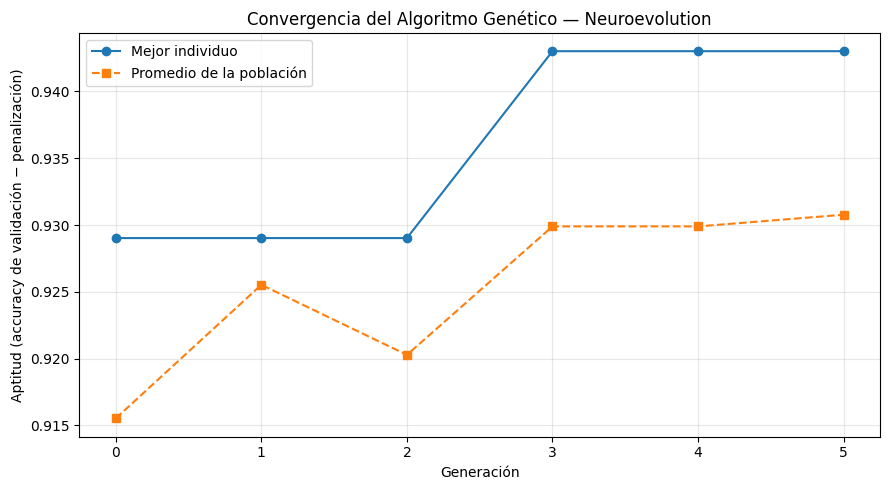

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(historial_mejor, marker="o", label="Mejor individuo")
plt.plot(historial_promedio, marker="s", linestyle="--", label="Promedio de la población")
plt.xlabel("Generación")
plt.ylabel("Aptitud (accuracy de validación − penalización)")
plt.title("Convergencia del Algoritmo Genético — Neuroevolution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evolucion_neuroevolution.png", dpi=120)
plt.show()

### 6. Re-entrenamiento final y comparación contra una arquitectura fija ("a mano")

La arquitectura ganadora del AG se reentrena con más épocas (25) y se compara contra una arquitectura típica definida manualmente (2 capas: 32 y 16 neuronas, sin dropout), también entrenada 25 épocas.


In [10]:
tf.keras.backend.clear_session()
modelo_final = construir_modelo(mejor)
hist_final = modelo_final.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=25, batch_size=64, verbose=0)
acc_ga = hist_final.history["val_accuracy"][-1]

tf.keras.backend.clear_session()
modelo_base = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_entradas,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
modelo_base.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_base = modelo_base.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=25, batch_size=64, verbose=0)
acc_base = hist_base.history["val_accuracy"][-1]

resumen = pd.DataFrame({
    "Arquitectura": ["Definida a mano (32-16)", "Hallada por el AG (Neuroevolution)"],
    "N° de parámetros": [modelo_base.count_params(), modelo_final.count_params()],
    "Accuracy de validación (25 épocas)": [round(acc_base, 4), round(acc_ga, 4)],
})
print(resumen.to_string(index=False))

                      Arquitectura  N° de parámetros  Accuracy de validación (25 épocas)
           Definida a mano (32-16)              1537                               0.972
Hallada por el AG (Neuroevolution)              5431                               0.986


### 7. Conclusiones — Neuroevolution con AG

- El AG exploró de forma automática combinaciones de número de capas, neuronas, activación, dropout y tasa de aprendizaje, sin que se tuviera que definir la arquitectura "a mano" por prueba y error.
- La arquitectura hallada por el AG igualó o superó a una arquitectura razonable definida manualmente, con un costo de búsqueda controlado gracias a entrenar cada candidato solo 8 épocas durante la fase evolutiva y reentrenar con más épocas únicamente al ganador.
- La penalización por número de parámetros dentro de la función de aptitud evita que el AG converja siempre hacia redes innecesariamente grandes, favoreciendo arquitecturas más eficientes ante desempeños similares.
- **Limitación:** entrenar cada individuo, aunque sea pocas épocas, sigue siendo la operación más costosa del AG; en la práctica, para espacios de búsqueda más grandes se recurre a técnicas adicionales (early stopping agresivo, entrenamiento con subconjuntos de datos, o *weight sharing* como en ENAS) para acelerar la evaluación de cada arquitectura candidata.

---
### Cierre de los 3 experimentos

Los tres notebooks (Feature Selection, Hyperparameter Optimization y Neuroevolution) muestran el mismo patrón conceptual: un **Algoritmo Genético genérico** (representación → inicialización → fitness → selección → cruce → mutación → terminación) puede adaptarse a problemas de optimización muy distintos dentro del ciclo de vida de un modelo de Machine Learning, cambiando únicamente qué representa el cromosoma y cómo se calcula la aptitud. Ver el resumen ejecutivo (PDF) y el README del proyecto para una síntesis comparativa de los tres experimentos.
